# Нахождение корней уравнений

In [39]:
import sys

sys.path.append('..')

### 1. Метод последовательного поиска

##### Пример:

$$x^3 - 3x^2 - 5x + 9 = 0$$

Нарисуем графики функции:

$$y = x^3$$

и 

$$z = 3x^2 + 5x - 9$$

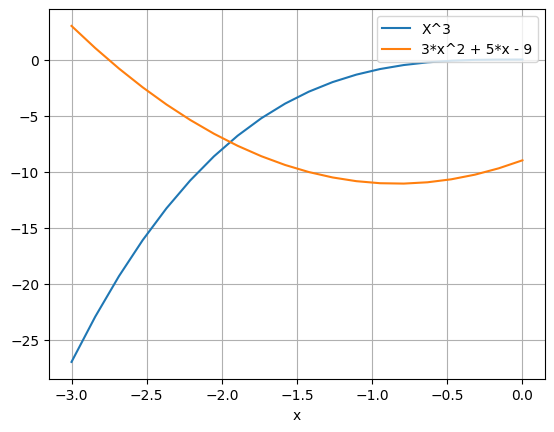

In [40]:
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(-3, 0, 20)

y = x**3
z = 3*x**2 + 5*x - 9

plt.xlabel('x')
plt.grid(True)
plt.plot(x, y, label='X^3')
plt.plot(x, z, label='3*x^2 + 5*x - 9')
plt.legend(loc='upper right')
plt.show()

Пусть:

$$f(x) = x^3 - 3x^2 - 5x + 9 $$

In [41]:
from math import log
from modules.equations.single import root_search

def f(x: float): return x**3 - 3*x**2 - 5*x + 9

x1, x2 = root_search(f, -3, 0, 0.1)

x1, x2

(-1.9999999999999991, -1.899999999999999)

In [42]:
f(x1), f(x2)

(-0.9999999999999822, 0.8110000000000159)

### 2. Метод бисекции

In [43]:
from modules.equations.single import bisection

x = bisection(f, -3, 0, 0.0001)

x

-1.9459991455078125

In [44]:
f(x)

-7.11237461992198e-05

### 3. Метод Риддера

In [45]:
from modules.equations.single import ridder

x, iter = ridder(f, -3, 0, 0.01, 100)

x, iter

(-1.94599520222806, 6)

In [46]:
f(x)

5.329070518200751e-15

### 4. Метод Ньютона-Рафсона

$$f'(x) = 3x^2 - 6x - 5$$

In [47]:
from modules.equations.single import newton_raphson

def df(x: float): return 3*x**2 - 6*x - 5.

x, iter = newton_raphson(f, df, -3, 0, 0.01, 100)

x, iter

(-1.9460394474989964, 3)

In [48]:
f(x)

-0.0007980543515433425

### 5. Метод Ньютона-Рафсона для системы уравнении

##### Пример:

$$x + y - 3 = 0$$

$$x^3 + x^2y - 12 = 0$$

In [49]:
from modules.equations.system import newton_raphson_system

def f(x: np.ndarray[np.double]) -> np.ndarray[np.double]:
    fx = np.zeros(len(x))

    fx[0] = x[1] + x[0] - 3.
    fx[1] = x[0]**3 + x[0]**2 * x[1] - 12.

    return fx

x = np.array([1., 1.])

x, iter = newton_raphson_system(f, x, 10**-4, 10**-9, 100)

x, iter

(array([2., 1.]), 7)

In [50]:
f(x)

array([0., 0.])